In [7]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from etna.datasets import TSDataset

In [28]:
gold_data = pd.read_excel('gold.xlsx')
silver_data = pd.read_excel('silver.xlsx')

silver_data

,Дата,Значение
0,2026-01-01,187.71
1,2025-12-31,187.71
2,2025-12-30,179.73
3,2025-12-29,174.20
4,2025-12-28,174.20
...,...,...
7443,2000-01-13,4.76
7444,2000-01-12,4.80
7445,2000-01-11,4.73
7446,2000-01-10,4.60


In [30]:
gold_df = gold_data.copy()
gold_df = gold_df.rename(columns={'Дата': 'timestamp', 'Значение': 'target'})
gold_df['segment'] = 'gold'

silver_df = silver_data.copy()
silver_df = silver_df.rename(columns={'Дата': 'timestamp', 'Значение': 'target'})
silver_df['segment'] = 'silver'

combined_df = pd.concat([gold_df, silver_df], ignore_index=True)
combined_df['timestamp'] = pd.to_datetime(combined_df['timestamp'])
combined_df = combined_df.sort_values(['timestamp', 'segment'])

combined_df

,timestamp,target,segment
7447,2000-01-06,246.67,gold
14895,2000-01-06,4.65,silver
7446,2000-01-10,252.45,gold
14894,2000-01-10,4.60,silver
7445,2000-01-11,258.83,gold
...,...,...,...
7450,2025-12-30,179.73,silver
1,2025-12-31,10907.88,gold
7449,2025-12-31,187.71,silver
0,2026-01-01,10907.88,gold


In [31]:
gold_only = combined_df[combined_df['segment'] == 'gold'].copy()
gold_ts = TSDataset(df=gold_only, freq='D')

gold_ts

segment,gold
feature,target
timestamp,
2000-01-06,246.67
2000-01-07,NaN
2000-01-08,NaN
2000-01-09,NaN
2000-01-10,252.45
...,...
2025-12-28,11192.43
2025-12-29,11192.43


In [35]:
gold_ts.info()

<class 'etna.datasets.TSDataset'>
num_segments: 1
num_exogs: 0
num_regressors: 0
num_known_future: 0
freq: D
end_timestamp: 2026-01-01 00:00:00
         start_timestamp  length  num_missing
segments                                     
gold          2000-01-06    9493         2045


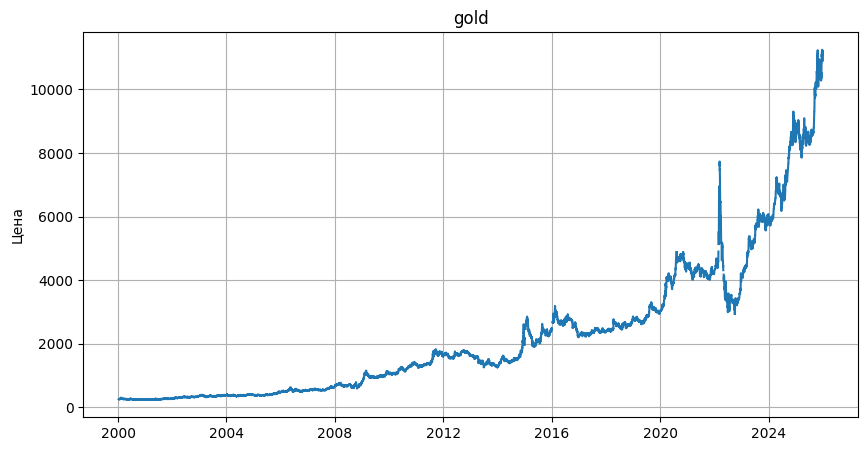

In [41]:
gold_ts.plot()
plt.ylabel('Цена')
plt.show()

In [42]:
silver_only = combined_df[combined_df['segment'] == 'silver'].copy()
silver_ts = TSDataset(df=silver_only, freq='D')

silver_ts

segment,silver
feature,target
timestamp,
2000-01-06,4.65
2000-01-07,NaN
2000-01-08,NaN
2000-01-09,NaN
2000-01-10,4.60
...,...
2025-12-28,174.20
2025-12-29,174.20


In [43]:
silver_ts.info()

<class 'etna.datasets.TSDataset'>
num_segments: 1
num_exogs: 0
num_regressors: 0
num_known_future: 0
freq: D
end_timestamp: 2026-01-01 00:00:00
         start_timestamp  length  num_missing
segments                                     
silver        2000-01-06    9493         2045


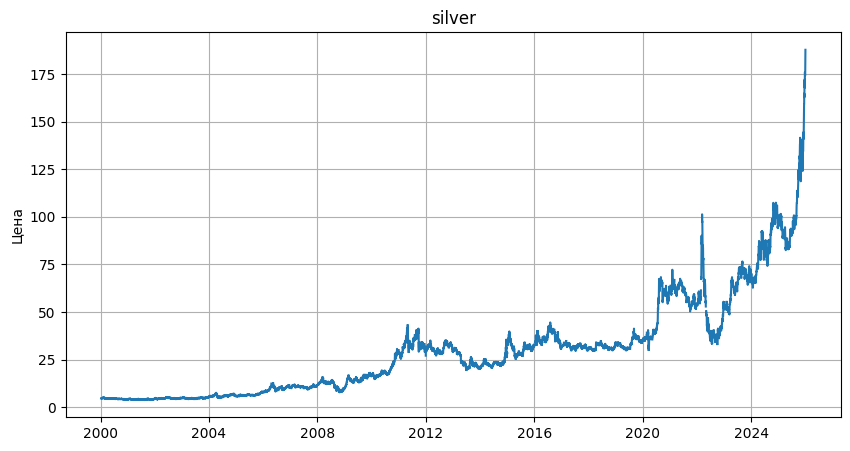

In [44]:
silver_ts.plot()
plt.ylabel('Цена')
plt.show()

In [45]:
wide_df = TSDataset.to_dataset(combined_df)
multivariate_ts = TSDataset(df=wide_df, freq='D')

multivariate_ts

segment,gold,silver
feature,target,target
timestamp,,
2000-01-06,246.67,4.65
2000-01-07,NaN,NaN
2000-01-08,NaN,NaN
2000-01-09,NaN,NaN
2000-01-10,252.45,4.60
...,...,...
2025-12-28,11192.43,174.20
2025-12-29,11192.43,174.20


In [46]:
multivariate_ts.info()

<class 'etna.datasets.TSDataset'>
num_segments: 2
num_exogs: 0
num_regressors: 0
num_known_future: 0
freq: D
end_timestamp: 2026-01-01 00:00:00
         start_timestamp  length  num_missing
segments                                     
gold          2000-01-06    9493         2045
silver        2000-01-06    9493         2045


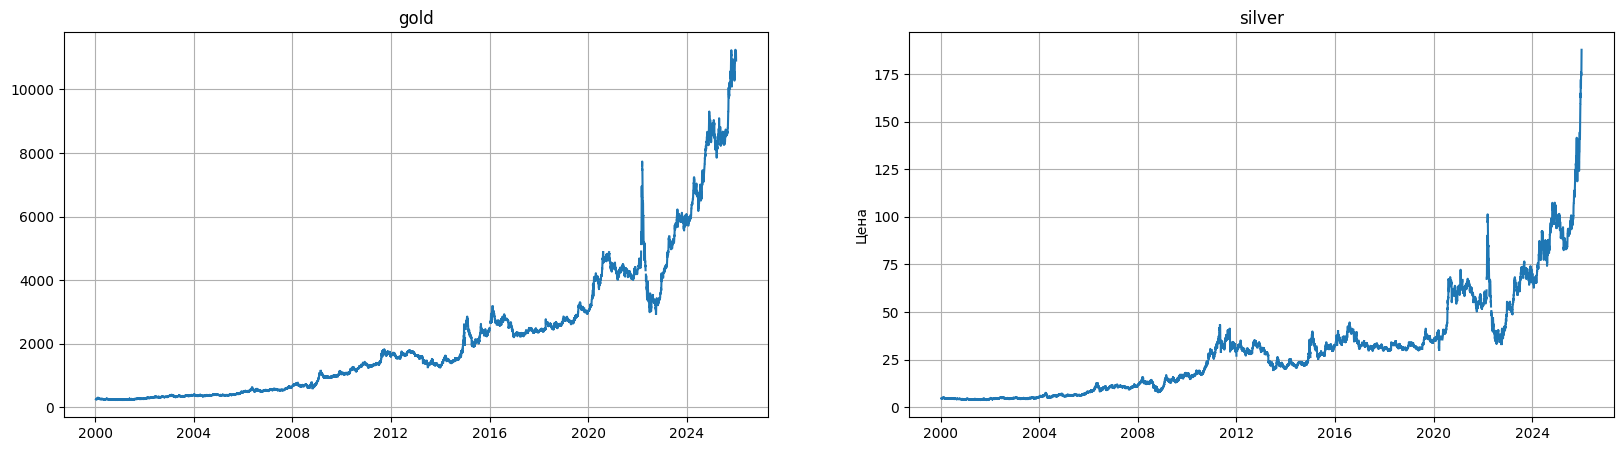

In [47]:
multivariate_ts.plot()
plt.ylabel('Цена')
plt.show()